# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Dian Atmoyo
- **Email:** dianatmoyo.w@gmail.com
- **ID Dicoding:** dian_atmoyo

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Kategori produk apa yang menghasilkan total revenue tertinggi selama periode September 2016 hingga Oktober 2018?

- **Pertanyaan 2:** Bagaimana tren jumlah transaksi pelanggan per bulan selama periode September 2016 hingga Oktober 2018?
- **Pertanyaan 3:** Bagaimana tingkat kepuasan pelanggan pada setiap kategori produk berdasarkan skor ulasan (review score) selama periode September 2016 hingga Oktober 2018?

## Import Semua Packages/Library yang Digunakan

Pada tahap ini dilakukan import berbagai library yang akan digunakan selama proses analisis data. Library yang digunakan mencakup manipulasi data, visualisasi data, pengolahan tanggal, dan konfigurasi notebook untuk mempermudah proses eksplorasi dan analisis.

In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Date and Time Processing
from datetime import datetime

# Notebook Configuration
import warnings
warnings.filterwarnings("ignore")

# Visualization Style
sns.set_style("whitegrid")

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Display Configuration
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

## Data Wrangling

Pada tahap ini dilakukan proses pengumpulan, pemeriksaan, dan pembersihan data untuk memastikan data yang digunakan memiliki kualitas yang baik dan siap untuk dianalisis.

### Gathering Data

Pada tahap ini dilakukan proses ekstraksi dataset dari file ZIP dan pemuatan data yang diperlukan ke dalam DataFrame. Dataset yang digunakan berasal dari E-Commerce Public Dataset dan terdiri dari beberapa tabel yang saling berhubungan.

#### Load df ...

In [5]:
# Memuat dataset pelanggan
customers_df = pd.read_csv("data/customers_dataset.csv")

# Memuat dataset transaksi
orders_df = pd.read_csv("data/orders_dataset.csv")

# Memuat dataset detail produk dalam transaksi
order_items_df = pd.read_csv("data/order_items_dataset.csv")

# Memuat dataset ulasan pelanggan
order_reviews_df = pd.read_csv("data/order_reviews_dataset.csv")

# Memuat dataset produk
products_df = pd.read_csv("data/products_dataset.csv")

# Memuat dataset terjemahan kategori produk
translation_df = pd.read_csv(
    "data/product_category_name_translation.csv"
)

In [6]:
# Menampilkan sampel data pelanggan
customers_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [7]:
# Menampilkan sampel data transaksi
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [8]:
# Menampilkan sampel data detail produk dalam transaksi
order_items_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [9]:
# Menampilkan sampel data ulasan pelanggan
order_reviews_df.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [10]:
# Menampilkan sampel data produk
products_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [11]:
# Menampilkan sampel data terjemahan kategori produk
translation_df.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [13]:
print("Customers :", customers_df.shape)
print("Orders :", orders_df.shape)
print("Order Items :", order_items_df.shape)
print("Reviews :", order_reviews_df.shape)
print("Products :", products_df.shape)
print("Translation :", translation_df.shape)

Customers : (99441, 5)
Orders : (99441, 8)
Order Items : (112650, 7)
Reviews : (99224, 7)
Products : (32951, 9)
Translation : (71, 2)


**Insight:** (Opsional)
- Dataset terdiri dari beberapa tabel yang saling berhubungan melalui customer_id, order_id, dan product_id.
- Data transaksi tersimpan pada orders_dataset dan order_items_dataset.
- Data kategori produk tersimpan pada products_dataset.
- Data kepuasan pelanggan tersimpan pada order_reviews_dataset.
- Data pelanggan tersimpan pada customers_dataset.
- Dataset yang dimuat telah mencakup seluruh kebutuhan analisis untuk menjawab pertanyaan bisnis dan melakukan RFM Analysis.

### Assessing Data

Pada tahap ini dilakukan pemeriksaan kualitas data untuk mengidentifikasi berbagai permasalahan yang dapat memengaruhi hasil analisis. Pemeriksaan meliputi struktur data, tipe data, missing values, data duplikat, serta konsistensi data.

#### Identifying ... problem

Memeriksa Struktur Dataset

In [14]:
customers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [15]:
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [16]:
order_items_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [17]:
order_reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


In [18]:
products_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [19]:
translation_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


Memeriksa Missing Values

In [20]:
datasets = {
    "customers": customers_df,
    "orders": orders_df,
    "order_items": order_items_df,
    "reviews": order_reviews_df,
    "products": products_df,
    "translation": translation_df
}

for name, df in datasets.items():
    print(f"\nMissing Values pada {name}")
    print(df.isna().sum())


Missing Values pada customers
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Missing Values pada orders
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Missing Values pada order_items
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

Missing Values pada reviews
review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer

Memeriksa Data Duplikat

In [21]:
for name, df in datasets.items():
    print(f"{name}: {df.duplicated().sum()} duplicated rows")

customers: 0 duplicated rows
orders: 0 duplicated rows
order_items: 0 duplicated rows
reviews: 0 duplicated rows
products: 0 duplicated rows
translation: 0 duplicated rows


Memeriksa Ringkasan Statistik Untuk kolom numerik

In [22]:
products_df.describe()

,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


In [23]:
order_items_df.describe()

,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


In [24]:
order_reviews_df.describe()

,review_score
count,99224.000000
mean,4.086421
std,1.347579
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


Memeriksa Tipe Data Tanggal

In [25]:
orders_df.dtypes

,0
order_id,object
customer_id,object
order_status,object
order_purchase_timestamp,object
order_approved_at,object
order_delivered_carrier_date,object
order_delivered_customer_date,object
order_estimated_delivery_date,object


**Steps to Take:**
- Memeriksa Struktur Dataset
- Memeriksa Missing Values
- Memeriksa Data Duplikat
- Memeriksa Ringkasan Statistik
- Memeriksa Tipe Data Tanggal




**Insight:**

Berdasarkan proses assessing data, ditemukan beberapa permasalahan kualitas data yang perlu diperhatikan sebelum analisis dilakukan.

1. Dataset orders memiliki missing values pada kolom order_approved_at, order_delivered_carrier_date, dan order_delivered_customer_date. Missing values ini kemungkinan disebabkan oleh pesanan yang dibatalkan atau belum selesai diproses.

2. Dataset products memiliki missing values pada beberapa atribut produk seperti product_category_name, product_name_lenght, product_description_lenght, dan product_photos_qty.

3. Dataset reviews memiliki banyak missing values pada kolom review_comment_title dan review_comment_message. Namun kolom tersebut tidak digunakan dalam analisis sehingga tidak memerlukan penanganan khusus.

4. Beberapa kolom tanggal pada dataset orders masih bertipe object dan perlu dikonversi menjadi datetime.

5. Tidak ditemukan data duplikat pada seluruh dataset yang digunakan sehingga tidak diperlukan proses penghapusan duplikasi.

### Cleaning Data

Pada tahap ini dilakukan proses pembersihan data berdasarkan permasalahan yang ditemukan pada tahap assessing data. Proses cleaning bertujuan meningkatkan kualitas data sehingga hasil analisis menjadi lebih akurat dan dapat dipercaya.

#### Fixing ... problem

Menangani Missing Value pada Products Dataset

In [29]:
#Missing Value Kategori Produk
products_df["product_category_name"] = (
    products_df["product_category_name"]
    .fillna("Unknown")
)

In [31]:
# Missing Value Atribut Produk
# Cek
products_df[
    [
        "product_name_lenght",
        "product_description_lenght",
        "product_photos_qty",
        "product_weight_g",
        "product_length_cm",
        "product_height_cm",
        "product_width_cm"
    ]
].isna().sum()

,0
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2


In [32]:
# Isi dengan Median
numeric_columns = [
    "product_name_lenght",
    "product_description_lenght",
    "product_photos_qty",
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm"
]

for col in numeric_columns:
    products_df[col].fillna(
        products_df[col].median(),
        inplace=True
    )

Mengubah Tipe Data Tanggal

In [33]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    orders_df[col] = pd.to_datetime(
        orders_df[col]
    )

In [34]:
# Review Dataset
order_reviews_df["review_creation_date"] = pd.to_datetime(
    order_reviews_df["review_creation_date"]
)

order_reviews_df["review_answer_timestamp"] = pd.to_datetime(
    order_reviews_df["review_answer_timestamp"]
)

Verifikasi Hasil Cleaning

In [35]:
datasets_cleaned = {
    "customers": customers_df,
    "orders": orders_df,
    "order_items": order_items_df,
    "reviews": order_reviews_df,
    "products": products_df,
    "translation": translation_df
}

for name, df in datasets_cleaned.items():
    print(f"\nMissing Values pada {name}")
    print(df.isna().sum())


Missing Values pada customers
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Missing Values pada orders
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Missing Values pada order_items
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

Missing Values pada reviews
review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer

In [36]:
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


**Insight:**

Proses cleaning data berhasil dilakukan dengan beberapa tindakan sebagai berikut:

1. Missing values pada kolom product_category_name diisi dengan nilai "Unknown" untuk mempertahankan data produk yang masih dapat digunakan dalam analisis.

2. Missing values pada atribut numerik produk seperti product_name_lenght, product_description_lenght, product_photos_qty, serta dimensi produk diisi menggunakan nilai median untuk mengurangi pengaruh nilai ekstrem.

3. Kolom tanggal pada dataset orders dan reviews berhasil dikonversi menjadi tipe data datetime sehingga siap digunakan untuk analisis berbasis waktu.

4. Missing values pada review_comment_title dan review_comment_message tidak ditangani karena kedua kolom tersebut tidak digunakan dalam analisis yang dilakukan.

5. Setelah proses cleaning, dataset siap digunakan pada tahap Exploratory Data Analysis (EDA).

## Exploratory Data Analysis (EDA)

Pada tahap ini dilakukan eksplorasi data untuk memahami pola, tren, dan hubungan antar variabel yang relevan dengan pertanyaan bisnis yang telah ditentukan. Hasil eksplorasi akan digunakan sebagai dasar dalam proses visualisasi dan pengambilan kesimpulan.

### Explore ...

Pertanyaan Bisnis 1

Kategori produk apa yang menghasilkan total revenue tertinggi selama periode September 2016 hingga Oktober 2018?

In [37]:
# Menggabungkan Dataset Produk dan Order Items
sales_df = order_items_df.merge(
    products_df,
    on="product_id",
    how="left"
)

In [38]:
# Menambahkan Nama Kategori Bahasa Inggris
sales_df = sales_df.merge(
    translation_df,
    on="product_category_name",
    how="left"
)

In [39]:
# Menghitung Revenue per Kategori
revenue_by_category = (
    sales_df
    .groupby("product_category_name_english")["price"]
    .sum()
    .sort_values(ascending=False)
)

revenue_by_category.head(10)

,price
product_category_name_english,
health_beauty,1258681.34
watches_gifts,1205005.68
bed_bath_table,1036988.68
sports_leisure,988048.97
computers_accessories,911954.32
furniture_decor,729762.49
cool_stuff,635290.85
housewares,632248.66
auto,592720.11


**Insight:**

Hasil eksplorasi menunjukkan bahwa beberapa kategori produk memberikan kontribusi revenue yang jauh lebih besar dibandingkan kategori lainnya. Informasi ini dapat digunakan untuk menentukan kategori produk prioritas dalam strategi pemasaran dan pengelolaan inventaris.

Pertanyaan Bisnis 2

Bagaimana tren jumlah transaksi pelanggan per bulan selama periode September 2016 hingga Oktober 2018?

In [40]:
# Membuat Data Bulanan
orders_df["year_month"] = (
    orders_df["order_purchase_timestamp"]
    .dt.to_period("M")
)

In [41]:
# Menghitung Jumlah Transaksi Bulanan
monthly_orders = (
    orders_df
    .groupby("year_month")
    .size()
    .reset_index(name="total_orders")
)

monthly_orders.head()

,year_month,total_orders
0,2016-09,4
1,2016-10,324
2,2016-12,1
3,2017-01,800
4,2017-02,1780


In [42]:
# Melihat Tren
monthly_orders.sort_values(
    by="year_month"
).tail()

,year_month,total_orders
20,2018-06,6167
21,2018-07,6292
22,2018-08,6512
23,2018-09,16
24,2018-10,4


**Insight:**

Jumlah transaksi pelanggan mengalami fluktuasi dari bulan ke bulan. Analisis tren transaksi membantu mengidentifikasi periode dengan aktivitas pembelian tinggi maupun rendah sehingga perusahaan dapat menyesuaikan strategi promosi dan persediaan produk.

Pertanyaan Bisnis 3

Bagaimana tingkat kepuasan pelanggan pada setiap kategori produk berdasarkan skor ulasan?

In [43]:
# Menggabungkan Dataset
review_product_df = (
    order_reviews_df
    .merge(order_items_df, on="order_id")
    .merge(products_df, on="product_id")
    .merge(
        translation_df,
        on="product_category_name",
        how="left"
    )
)

In [44]:
# Menghitung Rata-rata Review Score
review_by_category = (
    review_product_df
    .groupby("product_category_name_english")["review_score"]
    .mean()
    .sort_values(ascending=False)
)

review_by_category.head(10)

,review_score
product_category_name_english,
cds_dvds_musicals,4.642857
fashion_childrens_clothes,4.500000
books_general_interest,4.446266
costruction_tools_tools,4.444444
flowers,4.419355
books_imported,4.400000
books_technical,4.368421
food_drink,4.315412
luggage_accessories,4.315257


In [45]:
# Fokus pada Kategori dengan Jumlah Review yang Memadai
review_summary = (
    review_product_df
    .groupby("product_category_name_english")
    .agg({
        "review_score": ["mean", "count"]
    })
)

review_summary.columns = [
    "avg_review_score",
    "total_reviews"
]

review_summary = review_summary[
    review_summary["total_reviews"] >= 50
]

review_summary.sort_values(
    by="avg_review_score",
    ascending=False
).head(10)

,avg_review_score,total_reviews
product_category_name_english,,
books_general_interest,4.446266,549
costruction_tools_tools,4.444444,99
books_imported,4.400000,60
books_technical,4.368421,266
food_drink,4.315412,279
luggage_accessories,4.315257,1088
small_appliances_home_oven_and_coffee,4.302632,76
fashion_shoes,4.233716,261
food,4.218182,495


**Insight:**

Rata-rata review score menunjukkan tingkat kepuasan pelanggan terhadap masing-masing kategori produk. Kategori dengan skor tinggi menunjukkan pengalaman pelanggan yang baik, sedangkan kategori dengan skor rendah dapat menjadi fokus evaluasi untuk meningkatkan kualitas produk maupun layanan.

Tambahan


In [46]:
# Statistik Revenue
sales_df["price"].describe()

,price
count,112650.000000
mean,120.653739
std,183.633928
min,0.850000
25%,39.900000
50%,74.990000
75%,134.900000
max,6735.000000


In [47]:
# Distribusi Review Score
order_reviews_df["review_score"].value_counts().sort_index()

,count
review_score,
1,11424
2,3151
3,8179
4,19142
5,57328


In [48]:
# Status Pesanan
orders_df["order_status"].value_counts()

,count
order_status,
delivered,96478
shipped,1107
canceled,625
unavailable,609
invoiced,314
processing,301
created,5
approved,2


## Visualization & Explanatory Analysis

Pada tahap ini dilakukan visualisasi data untuk menjawab pertanyaan bisnis yang telah ditentukan. Visualisasi digunakan untuk mempermudah interpretasi pola, tren, dan informasi penting yang ditemukan selama proses eksplorasi data.

### Pertanyaan 1:

Kategori produk apa yang menghasilkan total revenue tertinggi selama periode September 2016 hingga Oktober 2018?

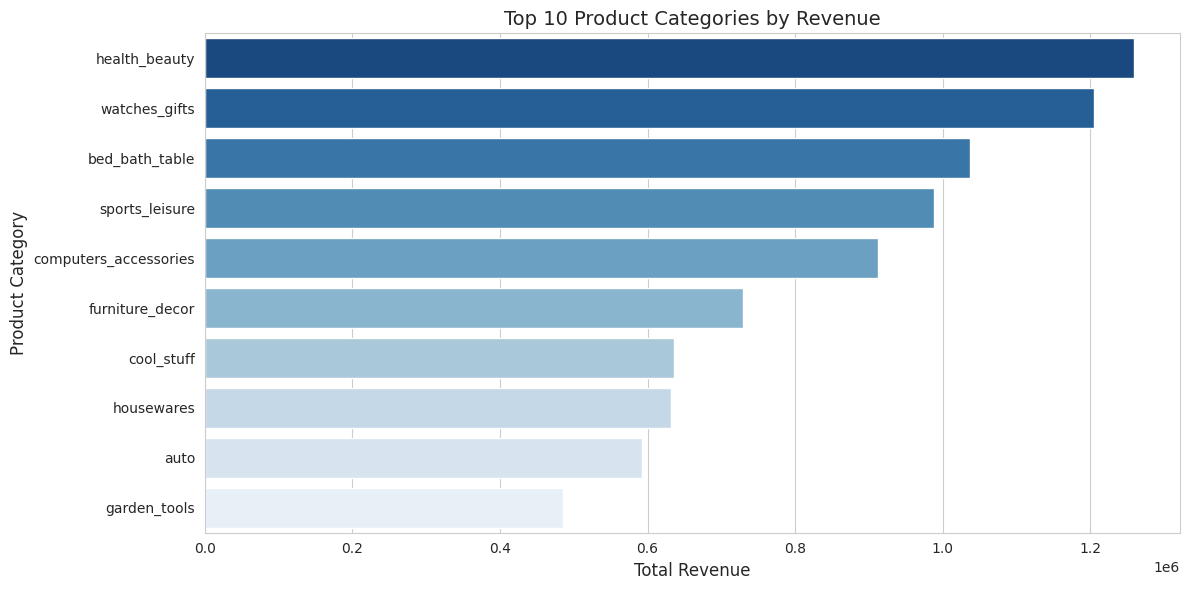

In [49]:
# Visualisasi
top_revenue_categories = revenue_by_category.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_revenue_categories.values,
    y=top_revenue_categories.index,
    palette="Blues_r"
)

plt.title("Top 10 Product Categories by Revenue", fontsize=14)
plt.xlabel("Total Revenue")
plt.ylabel("Product Category")

plt.tight_layout()
plt.show()

### Pertanyaan 2:

Bagaimana tren jumlah transaksi pelanggan per bulan selama periode September 2016 hingga Oktober 2018?

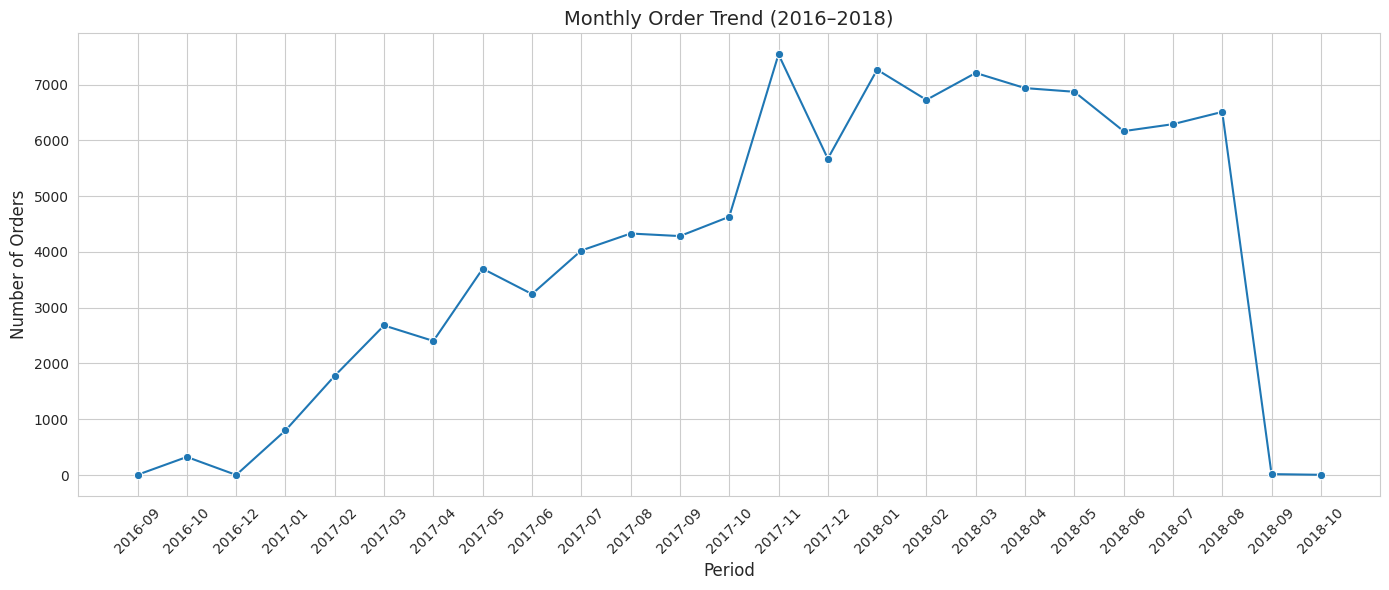

In [50]:
# Visualisasi
monthly_orders["year_month"] = monthly_orders["year_month"].astype(str)

plt.figure(figsize=(14,6))

sns.lineplot(
    data=monthly_orders,
    x="year_month",
    y="total_orders",
    marker="o"
)

plt.title("Monthly Order Trend (2016–2018)", fontsize=14)
plt.xlabel("Period")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Pertanyaan 3:

Bagaimana tingkat kepuasan pelanggan pada setiap kategori produk berdasarkan review score?

In [51]:
# Persiapan Data
top_review_categories = (
    review_summary
    .sort_values(
        by="avg_review_score",
        ascending=False
    )
    .head(10)
)

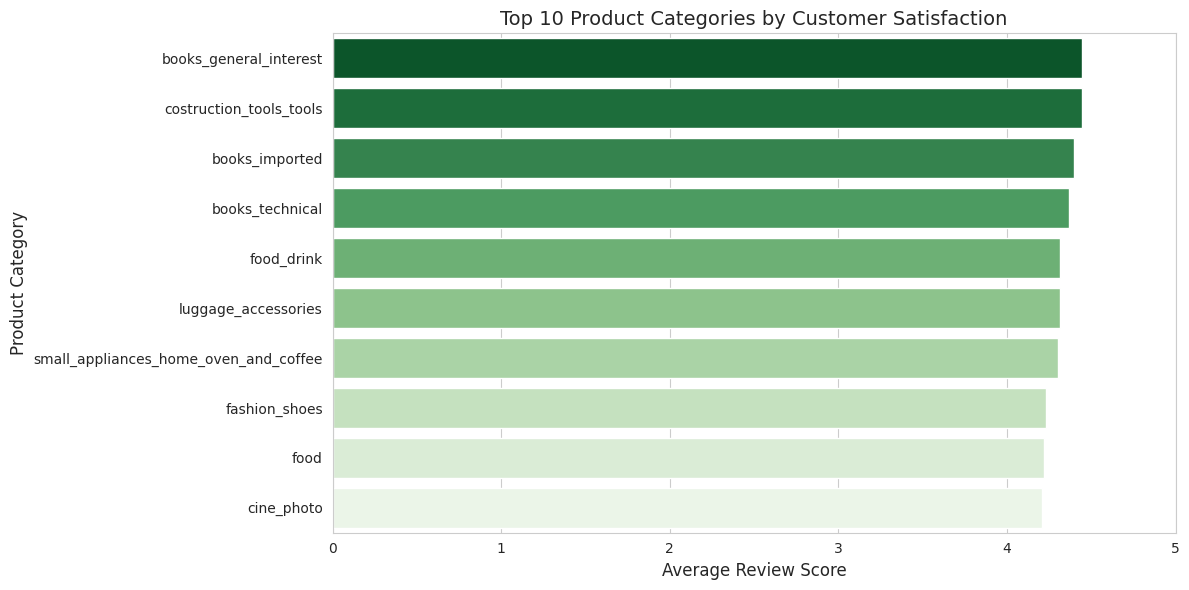

In [52]:
# Visualisasi
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_review_categories["avg_review_score"],
    y=top_review_categories.index,
    palette="Greens_r"
)

plt.title("Top 10 Product Categories by Customer Satisfaction", fontsize=14)
plt.xlabel("Average Review Score")
plt.ylabel("Product Category")

plt.xlim(0,5)

plt.tight_layout()
plt.show()

**Insight:**
- Berdasarkan visualisasi, terdapat beberapa kategori produk yang mendominasi total revenue perusahaan selama periode pengamatan. Kategori-kategori tersebut dapat dijadikan prioritas dalam strategi pemasaran, pengelolaan stok, dan pengembangan produk karena memberikan kontribusi terbesar terhadap pendapatan perusahaan.
- Jumlah transaksi pelanggan mengalami fluktuasi sepanjang periode pengamatan. Beberapa bulan menunjukkan peningkatan transaksi yang signifikan, sedangkan periode lainnya mengalami penurunan. Informasi ini dapat digunakan untuk mengidentifikasi pola musiman dan menentukan waktu yang tepat untuk menjalankan program promosi maupun pengelolaan persediaan produk.
- Visualisasi menunjukkan bahwa beberapa kategori produk memperoleh rata-rata review score yang lebih tinggi dibandingkan kategori lainnya. Kategori dengan skor tinggi menunjukkan tingkat kepuasan pelanggan yang baik, sedangkan kategori dengan skor lebih rendah dapat menjadi fokus evaluasi untuk meningkatkan kualitas produk maupun layanan.

Tambahan Distribusi Review Score

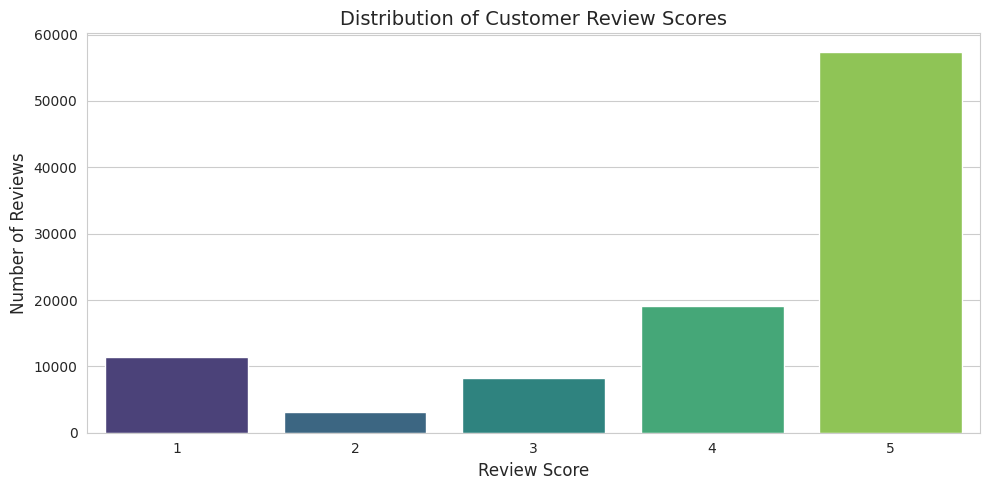

In [67]:
plt.figure(figsize=(10,5))

sns.countplot(
    x="review_score",
    data=order_reviews_df,
    palette="viridis"
)

plt.title("Distribution of Customer Review Scores")
plt.xlabel("Review Score")
plt.ylabel("Number of Reviews")

plt.tight_layout()
plt.show()

## Analisis Lanjutan

RFM Analysis dilakukan untuk memahami perilaku pelanggan berdasarkan waktu transaksi terakhir (Recency), frekuensi transaksi (Frequency), dan total nilai transaksi (Monetary). Hasil analisis ini dapat membantu perusahaan dalam mengidentifikasi pelanggan yang paling bernilai dan menentukan strategi pemasaran yang lebih efektif.

Membuat Dataset RFM

In [53]:
# Menggabungkan Orders dan Order Items
rfm_df = orders_df.merge(
    order_items_df,
    on="order_id",
    how="inner"
)

In [54]:
# Menentukan Tanggal Referensi
# Gunakan tanggal transaksi terbaru dalam dataset.
snapshot_date = orders_df[
    "order_purchase_timestamp"
].max() + pd.Timedelta(days=1)

snapshot_date

Timestamp('2018-10-18 17:30:18')

Menghitung RFM

In [55]:
rfm = rfm_df.groupby("customer_id").agg({
    "order_purchase_timestamp": lambda x: (
        snapshot_date - x.max()
    ).days,
    "order_id": "nunique",
    "price": "sum"
}).reset_index()

In [56]:
# rename kolom
rfm.columns = [
    "customer_id",
    "recency",
    "frequency",
    "monetary"
]

In [57]:
rfm.head()

,customer_id,recency,frequency,monetary
0,00012a2ce6f8dcda20d059ce98491703,338,1,89.80
1,000161a058600d5901f007fab4c27140,459,1,54.90
2,0001fd6190edaaf884bcaf3d49edf079,597,1,179.99
3,0002414f95344307404f0ace7a26f1d5,428,1,149.90
4,000379cdec625522490c315e70c7a9fb,199,1,93.00


Statistik RFM

In [58]:
rfm.describe()

,recency,frequency,monetary
count,98666.000000,98666.0,98666.000000
mean,290.343067,1.0,137.754076
std,153.389890,0.0,210.645145
min,45.000000,1.0,0.850000
25%,166.000000,1.0,45.900000
50%,271.000000,1.0,86.900000
75%,400.000000,1.0,149.900000
max,773.000000,1.0,13440.000000


Menentukan Segmentasi Pelanggan

In [59]:
# Recency Score
rfm["R_score"] = pd.qcut(
    rfm["recency"],
    q=4,
    labels=[4,3,2,1]
)

In [60]:
# Frequency Score
rfm["F_score"] = pd.qcut(
    rfm["frequency"].rank(method="first"),
    q=4,
    labels=[1,2,3,4]
)

In [61]:
# Monetary Score
rfm["M_score"] = pd.qcut(
    rfm["monetary"],
    q=4,
    labels=[1,2,3,4]
)

Membuat RFM Score

In [62]:
rfm["RFM_score"] = (
    rfm["R_score"].astype(str) +
    rfm["F_score"].astype(str) +
    rfm["M_score"].astype(str)
)

Membuat Customer Segment

In [63]:
def customer_segment(row):

    if row["R_score"] == 4 and row["F_score"] >= 3:
        return "Best Customers"

    elif row["F_score"] >= 3:
        return "Loyal Customers"

    elif row["M_score"] >= 3:
        return "Big Spenders"

    elif row["R_score"] <= 2:
        return "At Risk Customers"

    else:
        return "Potential Customers"

In [64]:
rfm["customer_segment"] = rfm.apply(
    customer_segment,
    axis=1
)

Distribusi Segment Pelanggan

In [65]:
segment_counts = (
    rfm["customer_segment"]
    .value_counts()
)

segment_counts

,count
customer_segment,
Loyal Customers,37094
Big Spenders,24503
At Risk Customers,12434
Potential Customers,12396
Best Customers,12239


Visualisasi RFM

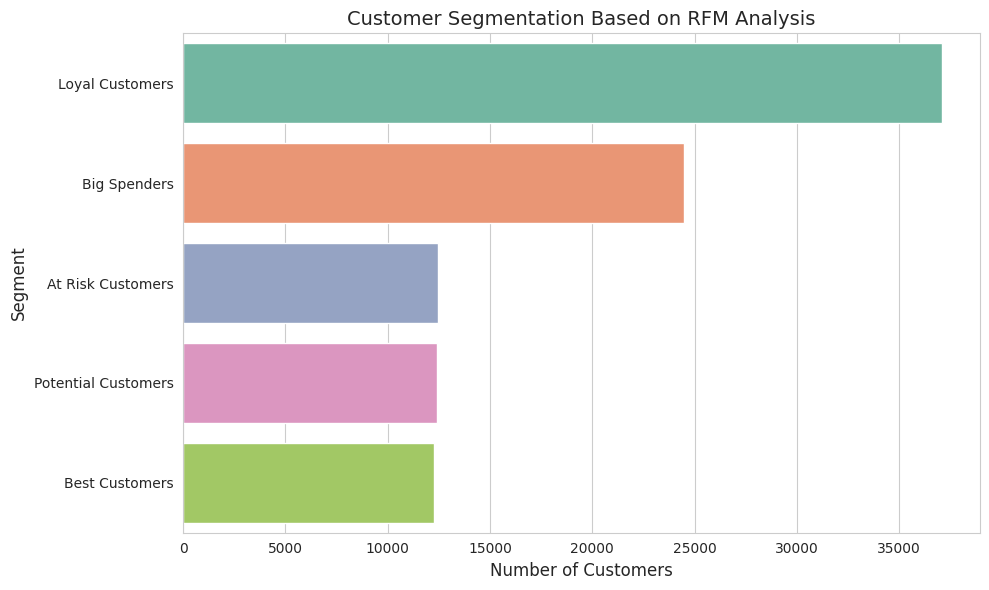

In [66]:
plt.figure(figsize=(10,6))

sns.countplot(
    y="customer_segment",
    data=rfm,
    order=rfm["customer_segment"]
          .value_counts()
          .index,
    palette="Set2"
)

plt.title("Customer Segmentation Based on RFM Analysis")
plt.xlabel("Number of Customers")
plt.ylabel("Segment")

plt.tight_layout()
plt.show()

**Insight:**

Hasil RFM Analysis menunjukkan bahwa pelanggan dapat dikelompokkan ke dalam beberapa segmen berdasarkan perilaku pembelian mereka.

- Best Customers merupakan pelanggan yang aktif bertransaksi dan memberikan kontribusi tinggi terhadap pendapatan perusahaan.
- Loyal Customers menunjukkan frekuensi transaksi yang tinggi dan berpotensi dipertahankan melalui program loyalitas.
- Big Spenders memiliki nilai transaksi yang besar sehingga penting untuk dipertahankan.
- At Risk Customers merupakan pelanggan yang sudah lama tidak melakukan transaksi sehingga memerlukan strategi reaktivasi.
- Potential Customers masih memiliki peluang untuk ditingkatkan menjadi pelanggan loyal melalui promosi yang tepat.

## Conclusion & Recommendation

Pada tahap ini disajikan kesimpulan berdasarkan hasil analisis yang telah dilakukan serta rekomendasi yang dapat digunakan sebagai dasar pengambilan keputusan bisnis.

- **Conclusion pertanyaan 1:** Kategori produk tertentu memberikan kontribusi revenue yang paling besar dibandingkan kategori lainnya selama periode September 2016 hingga Oktober 2018. Temuan ini menunjukkan bahwa pendapatan perusahaan tidak tersebar secara merata pada seluruh kategori produk, melainkan didominasi oleh beberapa kategori unggulan.

- **Conclusion pertanyaan 2:** Jumlah transaksi pelanggan mengalami fluktuasi dari bulan ke bulan selama periode pengamatan. Terdapat periode dengan peningkatan transaksi yang signifikan serta periode dengan penurunan aktivitas pembelian. Pola ini menunjukkan adanya kecenderungan musiman yang dapat dimanfaatkan dalam perencanaan bisnis.

- **Conclusion pertanyaan 3:** Tingkat kepuasan pelanggan berbeda pada setiap kategori produk. Beberapa kategori memperoleh rata-rata review score yang tinggi, menunjukkan pengalaman pelanggan yang baik. Sebaliknya, kategori dengan skor yang lebih rendah memerlukan evaluasi lebih lanjut untuk meningkatkan kualitas produk maupun layanan.

- **Analisis Lanjutan (RFM Analysis):** Hasil RFM Analysis menunjukkan bahwa pelanggan dapat dikelompokkan ke dalam beberapa segmen berdasarkan perilaku pembelian mereka. Terdapat pelanggan yang sangat aktif dan bernilai tinggi bagi perusahaan, pelanggan loyal yang rutin melakukan transaksi, serta pelanggan yang berisiko tidak kembali bertransaksi. Segmentasi ini memberikan gambaran yang lebih jelas mengenai karakteristik pelanggan dan potensi strategi yang dapat diterapkan.

**Rekomendasi Action Item:**

Berdasarkan hasil analisis yang telah dilakukan, beberapa rekomendasi yang dapat diterapkan adalah sebagai berikut:

1. Memprioritaskan promosi dan pengelolaan stok pada kategori produk dengan revenue tertinggi karena kategori tersebut memberikan kontribusi terbesar terhadap pendapatan perusahaan.

2. Memanfaatkan pola tren transaksi bulanan untuk menentukan waktu pelaksanaan promosi, kampanye pemasaran, dan pengelolaan persediaan produk secara lebih efektif.

3. Melakukan evaluasi terhadap kategori produk dengan rata-rata review score yang lebih rendah untuk meningkatkan kualitas produk, layanan pengiriman, maupun pengalaman pelanggan secara keseluruhan.

4. Memberikan program loyalitas khusus kepada segmen Best Customers dan Loyal Customers untuk mempertahankan tingkat retensi pelanggan dan meningkatkan nilai transaksi.

5. Menjalankan strategi reaktivasi seperti pemberian voucher, diskon khusus, atau kampanye pemasaran personal kepada segmen At Risk Customers agar kembali melakukan transaksi.

6. Mengembangkan strategi pemasaran yang berbeda untuk setiap segmen pelanggan berdasarkan hasil RFM Analysis sehingga aktivitas pemasaran menjadi lebih tepat sasaran dan efisien.

## Overall Insight

Analisis menunjukkan bahwa performa bisnis e-commerce dipengaruhi oleh kombinasi faktor penjualan produk, perilaku transaksi pelanggan, tingkat kepuasan pelanggan, serta karakteristik pelanggan berdasarkan RFM Analysis. Dengan memanfaatkan informasi tersebut, perusahaan dapat menyusun strategi pemasaran yang lebih efektif, meningkatkan pengalaman pelanggan, dan mengoptimalkan pertumbuhan bisnis secara berkelanjutan.

Membuat main_data.csv


In [68]:
# Menggabungkan data utama

main_df = orders_df.merge(
    customers_df,
    on="customer_id",
    how="left"
)

main_df = main_df.merge(
    order_items_df,
    on="order_id",
    how="left"
)

main_df = main_df.merge(
    products_df,
    on="product_id",
    how="left"
)

main_df = main_df.merge(
    translation_df,
    on="product_category_name",
    how="left"
)

main_df = main_df.merge(
    order_reviews_df[[
        "order_id",
        "review_score"
    ]],
    on="order_id",
    how="left"
)

In [69]:
main_df.to_csv(
    "dashboard/main_data.csv",
    index=False
)

In [70]:
main_df.shape

(114092, 29)

In [71]:
main_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,year_month,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017-10,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018-07,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,perfumery,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018-08,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,auto,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017-11,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0,pet_shop,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018-02,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,1.0,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0,stationery,5.0


In [72]:
main_df.shape

(114092, 29)